### Importing Required Libraries

This cell imports all the necessary libraries for building and training a 3D Convolutional Neural Network for video classification.

- **torch / torch.nn / torch.optim** → Core PyTorch modules for model building and optimization.
- **Dataset, DataLoader** → For creating custom datasets and loading data efficiently.
- **r3d_18, R3D_18_Weights** → Pretrained 3D ResNet-18 model for video classification.
- Additional utilities help with data handling and training workflows.

This setup prepares the environment for deep learning with video data.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.models.video import r3d_18, R3D_18_Weights
from decord import VideoReader, cpu
import numpy as np
import os
import random
from collections import defaultdict
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from sklearn.utils import resample
import matplotlib.pyplot as plt
from datetime import datetime


### Dataset Paths and Class Definitions

This cell defines the dataset structure and class labels.

- `DATA_ROOT` → Root directory containing video data.
- `VIOLENT_DIR` → Path to violent video samples.
- `NON_VIOLENT_DIR` → Path to non-violent video samples.
- `CLASSES` → List defining label order:
  - `0 → NonViolence`
  - `1 → Violence`

These paths are used to load and organize the dataset for training and evaluation.

In [7]:
DATA_ROOT       = '/home/heytanix/PCL_repository/data2'
VIOLENT_DIR     = os.path.join(DATA_ROOT, 'Violence')
NON_VIOLENT_DIR = os.path.join(DATA_ROOT, 'NonViolence')
CLASSES         = ['NonViolence', 'Violence']

CLIP_LEN    = 16
BATCH_SIZE  = 8
NUM_EPOCHS  = 20
NUM_WORKERS = 4

print(f"Violent dir exists:     {os.path.exists(VIOLENT_DIR)}")
print(f"Non-violent dir exists: {os.path.exists(NON_VIOLENT_DIR)}")


Violent dir exists:     True
Non-violent dir exists: True


### Finding MP4 Video Files

This function searches a given directory and collects all `.mp4` files.

Key functionality:
- Checks if the directory exists.
- Traverses subdirectories (if any).
- Returns a list of valid video file paths.

This helps dynamically build the dataset from the folder structure.

In [8]:
def find_mp4_files(directory):
    mp4_files = []
    if not os.path.exists(directory):
        print(f"WARNING: {directory} does not exist!")
        return mp4_files
    for root, _, files in os.walk(directory):
        for f in files:
            if f.lower().endswith('.mp4'):
                mp4_files.append(os.path.join(root, f))
    return mp4_files

violent_mp4s     = find_mp4_files(VIOLENT_DIR)
non_violent_mp4s = find_mp4_files(NON_VIOLENT_DIR)

print(f"Found {len(violent_mp4s)} violent MP4s")
print(f"Found {len(non_violent_mp4s)} non-violent MP4s")

if not violent_mp4s and not non_violent_mp4s:
    raise ValueError("No MP4 files found! Check DATA_ROOT path.")

# Label and combine
all_data = [(p, 1) for p in violent_mp4s] + [(p, 0) for p in non_violent_mp4s]
random.seed(42)
random.shuffle(all_data)

# Stratified split: 70% train, 15% val, 15% test
paths  = [d[0] for d in all_data]
labels = [d[1] for d in all_data]

from sklearn.model_selection import train_test_split
train_data, temp_data = train_test_split(all_data, test_size=0.30, stratify=labels, random_state=42)
temp_labels = [d[1] for d in temp_data]
val_data, test_data   = train_test_split(temp_data, test_size=0.50, stratify=temp_labels, random_state=42)

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")


Found 1000 violent MP4s
Found 951 non-violent MP4s
Train: 1365, Val: 293, Test: 293


### Dataset Balancing

This cell separates training samples into:
- Non-violent videos
- Violent videos

It prints the class distribution before balancing.

Purpose:
- To analyze dataset imbalance.
- To potentially apply balancing strategies (e.g., undersampling or oversampling).

Balanced datasets help prevent model bias toward dominant classes.

In [9]:
train_non_violent = [(p, l) for p, l in train_data if l == 0]
train_violent     = [(p, l) for p, l in train_data if l == 1]

print(f"Before balancing — Non-violent: {len(train_non_violent)}, Violent: {len(train_violent)}")

max_count = max(len(train_non_violent), len(train_violent))

if len(train_non_violent) < max_count:
    train_non_violent = resample(train_non_violent, n_samples=max_count, replace=True, random_state=42)
elif len(train_violent) < max_count:
    train_violent = resample(train_violent, n_samples=max_count, replace=True, random_state=42)

train_data_balanced = train_non_violent + train_violent
random.shuffle(train_data_balanced)

print(f"After balancing — Total: {len(train_data_balanced)}")
print(f"Non-violent: {sum(1 for _, l in train_data_balanced if l == 0)}, Violent: {sum(1 for _, l in train_data_balanced if l == 1)}")


Before balancing — Non-violent: 665, Violent: 700
After balancing — Total: 1400
Non-violent: 700, Violent: 700


### Custom Video Dataset Class

This cell defines a custom `VideoDataset` class inheriting from `torch.utils.data.Dataset`.

Main responsibilities:
- Stores video file paths and labels.
- Extracts fixed-length clips (`clip_len` frames).
- Applies optional transformations.
- Returns processed video tensors with corresponding labels.

This class enables PyTorch to load video clips efficiently during training.

In [10]:
class VideoDataset(Dataset):
    def __init__(self, data, clip_len=16, transform=None):
        self.video_paths = [d[0] for d in data]
        self.labels      = [d[1] for d in data]
        self.clip_len    = clip_len
        self.transform   = transform

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        try:
            vr = VideoReader(self.video_paths[idx], ctx=cpu(0))
            total_frames = len(vr)

            if total_frames >= self.clip_len:
                indices = np.linspace(0, total_frames - 1, self.clip_len, dtype=int)
            else:
                indices = list(range(total_frames))
                indices += [total_frames - 1] * (self.clip_len - total_frames)

            frames = vr.get_batch(indices).asnumpy().copy()   # contiguous memory
            frames = torch.from_numpy(frames).float() / 255.0
            frames = frames.permute(3, 0, 1, 2).contiguous()  # (C, T, H, W)

            if self.transform:
                frames = self.transform(frames)

            return frames, self.labels[idx]

        except Exception as e:
            print(f"Warning: Failed to load {self.video_paths[idx]}: {e}")
            return torch.zeros(3, self.clip_len, 112, 112), self.labels[idx]


### Video Resizing Transformation

This custom transformation resizes video frames.

Input format:
- `(C, T, H, W)` → Channels, Time, Height, Width

Functionality:
- Resizes each frame spatially.
- Maintains temporal dimension.
- Ensures consistent input size for the 3D CNN model.

Proper resizing is essential for compatibility with pretrained models.

In [11]:
class ResizeVideo:
    def __init__(self, size):
        self.size = size
    def __call__(self, video):
        C, T, H, W = video.shape
        video = video.reshape(C * T, H, W).unsqueeze(0)
        video = F.interpolate(video, size=self.size, mode='bilinear', align_corners=False)
        video = video.squeeze(0).reshape(C, T, *self.size)
        return video

class NormalizeVideo:
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean).view(3, 1, 1, 1)
        self.std  = torch.tensor(std).view(3, 1, 1, 1)
    def __call__(self, video):
        return (video - self.mean) / self.std

class VideoAugmentation:
    def __call__(self, video):
        if random.random() > 0.5:
            video = torch.flip(video, dims=[3])
        brightness = random.uniform(0.8, 1.2)
        contrast   = random.uniform(0.8, 1.2)
        video = torch.clamp(video * brightness, 0, 1)
        mean  = video.mean(dim=[2, 3], keepdim=True)
        video = torch.clamp((video - mean) * contrast + mean, 0, 1)
        if random.random() > 0.5:
            video = torch.clamp(video + torch.randn_like(video) * 0.02, 0, 1)
        T = video.shape[1]
        max_drop = max(1, T // 8)
        drop = random.randint(0, max_drop)
        video = video[:, drop:, :, :] if random.random() > 0.5 else video[:, :T - drop, :, :]
        C, t, H, W = video.shape
        if t != T:
            video = F.interpolate(video.unsqueeze(0), size=(T, H, W), mode='trilinear', align_corners=False).squeeze(0)
        return video

class VideoTransformCompose:
    def __init__(self, transforms_list):
        self.transforms_list = transforms_list
    def __call__(self, video):
        for t in self.transforms_list:
            video = t(video)
        return video

MEAN = [0.43216, 0.394666, 0.37645]
STD  = [0.22803, 0.22145,  0.216989]

transform_train = VideoTransformCompose([
    ResizeVideo((128, 128)),
    VideoAugmentation(),
    ResizeVideo((112, 112)),
    NormalizeVideo(MEAN, STD),
])
transform_val_test = VideoTransformCompose([
    ResizeVideo((112, 112)),
    NormalizeVideo(MEAN, STD),
])

train_dataset = VideoDataset(train_data_balanced, clip_len=CLIP_LEN, transform=transform_train)
val_dataset   = VideoDataset(val_data,            clip_len=CLIP_LEN, transform=transform_val_test)
test_dataset  = VideoDataset(test_data,           clip_len=CLIP_LEN, transform=transform_val_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")


Train batches: 175, Val batches: 37, Test batches: 37


### Model Initialization — 3D ResNet-18

This cell:
- Detects GPU availability.
- Loads pretrained `r3d_18` (trained on Kinetics-400).
- Modifies the final fully connected layer for binary classification.
- Moves the model to the selected device (CPU/GPU).

Transfer learning is used here to leverage pretrained spatio-temporal features.

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = r3d_18(weights=R3D_18_Weights.KINETICS400_V1)
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, 2)
)

for name, param in model.named_parameters():
    if 'fc' not in name:
        param.requires_grad = False

model = model.to(device)

backbone_params   = [p for n, p in model.named_parameters() if 'fc' not in n]
classifier_params = [p for n, p in model.named_parameters() if 'fc' in n]

optimizer = optim.Adam([
    {'params': backbone_params,   'lr': 1e-4, 'weight_decay': 1e-4},
    {'params': classifier_params, 'lr': 1e-3, 'weight_decay': 1e-4},
])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
criterion = nn.CrossEntropyLoss()

print(f"Backbone frozen. Training classifier head only for first 3 epochs.")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Using device: cuda
Backbone frozen. Training classifier head only for first 3 epochs.
Trainable params: 1,026


### Training Configuration & Early Stopping

This cell defines training control parameters:

- `UNFREEZE_EPOCH` → Epoch to start fine-tuning deeper layers.
- `PATIENCE` → Early stopping patience.
- `best_val_acc` / `best_val_loss` → Track best performance.
- `epochs_no_improve` → Counter for early stopping.

Purpose:
- Prevent overfitting.
- Stop training when validation performance stops improving.
- Enable progressive fine-tuning.

Starting training for 20 epochs...
  Batch [10/175] Loss: 0.7809
  Batch [20/175] Loss: 0.6093
  Batch [30/175] Loss: 0.5553
  Batch [40/175] Loss: 0.4707
  Batch [50/175] Loss: 0.4353
  Batch [60/175] Loss: 0.3231
  Batch [70/175] Loss: 0.3075
  Batch [80/175] Loss: 1.1145
  Batch [90/175] Loss: 0.9230
  Batch [100/175] Loss: 0.5967


[h264 @ 0x1400bdc0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x1400bdc0] error while decoding MB 98 31


  Batch [110/175] Loss: 0.4130
  Batch [120/175] Loss: 0.4247
  Batch [130/175] Loss: 0.6394
  Batch [140/175] Loss: 0.6847
  Batch [150/175] Loss: 0.3728
  Batch [160/175] Loss: 0.2313
  Batch [170/175] Loss: 0.2954

Epoch [1/20] (67s):
  Train Loss: 0.5185  Train Acc: 73.29%
  Val Loss:   0.2420  Val Acc:   91.81%
  LR: 0.001000
------------------------------------------------------------
  ✓ New best val accuracy: 91.81% — saved.
  Batch [10/175] Loss: 0.1869
  Batch [20/175] Loss: 0.2542


[h264 @ 0x368e3d00] mb_type 104 in P slice too large at 98 31
[h264 @ 0x368e3d00] error while decoding MB 98 31


  Batch [30/175] Loss: 0.5588
  Batch [40/175] Loss: 0.2400
  Batch [50/175] Loss: 0.2378
  Batch [60/175] Loss: 0.7589
  Batch [70/175] Loss: 0.4907
  Batch [80/175] Loss: 0.5943
  Batch [90/175] Loss: 0.5764
  Batch [100/175] Loss: 0.1392
  Batch [110/175] Loss: 0.3369
  Batch [120/175] Loss: 0.3946
  Batch [130/175] Loss: 0.4280
  Batch [140/175] Loss: 0.6748
  Batch [150/175] Loss: 0.4430
  Batch [160/175] Loss: 0.5476
  Batch [170/175] Loss: 0.7329

Epoch [2/20] (64s):
  Train Loss: 0.4166  Train Acc: 81.50%
  Val Loss:   0.1944  Val Acc:   93.52%
  LR: 0.001000
------------------------------------------------------------
  ✓ New best val accuracy: 93.52% — saved.
  Batch [10/175] Loss: 0.4078
  Batch [20/175] Loss: 1.2179
  Batch [30/175] Loss: 0.5886
  Batch [40/175] Loss: 0.0998
  Batch [50/175] Loss: 0.3120
  Batch [60/175] Loss: 0.2914
  Batch [70/175] Loss: 0.2530


...

  Batch [130/175] Loss: 0.0008
  Batch [140/175] Loss: 0.0000
  Batch [150/175] Loss: 0.0000
  Batch [160/175] Loss: 0.0009
  Batch [170/175] Loss: 0.3728

Epoch [18/20] (65s):
  Train Loss: 0.0128  Train Acc: 99.79%
  Val Loss:   0.1008  Val Acc:   96.93%
  LR: 0.000125
------------------------------------------------------------
  Batch [10/175] Loss: 0.0001
  Batch [20/175] Loss: 0.0000
  Batch [30/175] Loss: 0.0000
  Batch [40/175] Loss: 0.0000
  Batch [50/175] Loss: 0.0000
  Batch [60/175] Loss: 0.0000
  Batch [70/175] Loss: 0.0000
  Batch [80/175] Loss: 0.0000
  Batch [90/175] Loss: 0.0000
  Batch [100/175] Loss: 0.0000
  Batch [110/175] Loss: 0.0000
  Batch [120/175] Loss: 0.0000
  Batch [130/175] Loss: 0.0000
  Batch [140/175] Loss: 0.0000


[h264 @ 0x36bca540] mb_type 104 in P slice too large at 98 31
[h264 @ 0x36bca540] error while decoding MB 98 31


  Batch [150/175] Loss: 0.0000
  Batch [160/175] Loss: 0.0000
  Batch [170/175] Loss: 0.0000

Epoch [19/20] (72s):
  Train Loss: 0.0028  Train Acc: 99.93%
  Val Loss:   0.1122  Val Acc:   97.27%
  LR: 0.000125
------------------------------------------------------------
  Batch [10/175] Loss: 0.0000
  Batch [20/175] Loss: 0.0000
  Batch [30/175] Loss: 0.0001
  Batch [40/175] Loss: 0.0004


[h264 @ 0x36c16740] mb_type 104 in P slice too large at 98 31
[h264 @ 0x36c16740] error while decoding MB 98 31


  Batch [50/175] Loss: 0.0004
  Batch [60/175] Loss: 0.0001
  Batch [70/175] Loss: 0.0000
  Batch [80/175] Loss: 0.0000
  Batch [90/175] Loss: 0.1551
  Batch [100/175] Loss: 0.0650
  Batch [110/175] Loss: 0.0943
  Batch [120/175] Loss: 0.0002
  Batch [130/175] Loss: 0.0000
  Batch [140/175] Loss: 0.0001
  Batch [150/175] Loss: 0.0006
  Batch [160/175] Loss: 0.0000
  Batch [170/175] Loss: 0.0001

Epoch [20/20] (70s):
  Train Loss: 0.0197  Train Acc: 99.71%
  Val Loss:   0.1055  Val Acc:   96.59%
  LR: 0.000125
------------------------------------------------------------

Training complete! Best val accuracy: 97.27% at epoch 8


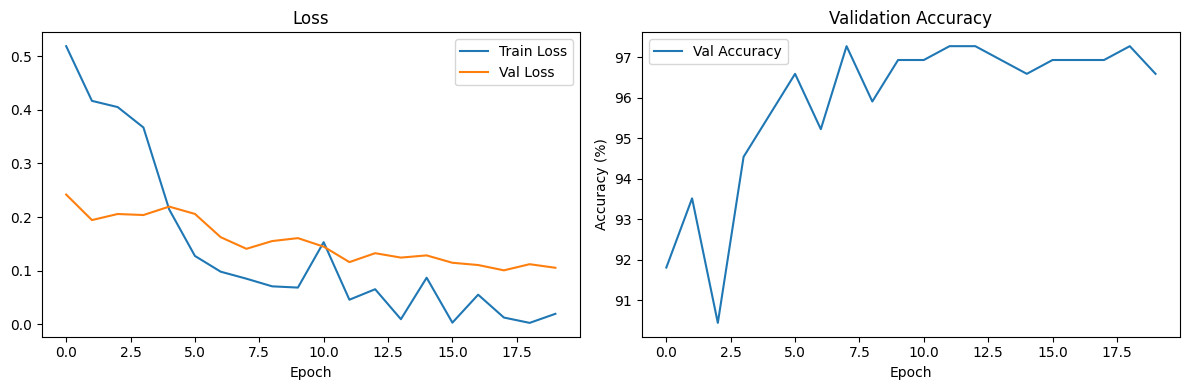

In [8]:
UNFREEZE_EPOCH    = 3
PATIENCE          = 5
best_val_acc      = 0.0
best_val_loss     = float('inf')
epochs_no_improve = 0
best_epoch        = 1
train_losses, val_losses, val_accuracies = [], [], []

print(f"Starting training for {NUM_EPOCHS} epochs...")

for epoch in range(NUM_EPOCHS):
    epoch_start = datetime.now()

    if epoch == UNFREEZE_EPOCH:
        for param in model.parameters():
            param.requires_grad = True
        print(f"\nEpoch {epoch+1}: Backbone unfrozen. Full model now training.")

    # ── Train ──
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for batch_idx, (videos, labels) in enumerate(train_loader):
        videos, labels = videos.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * videos.size(0)
        _, predicted  = outputs.max(1)
        correct       += predicted.eq(labels).sum().item()
        total         += labels.size(0)

        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch [{batch_idx+1}/{len(train_loader)}] Loss: {loss.item():.4f}")

    avg_train_loss = running_loss / total
    train_acc      = 100.0 * correct / total

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for videos, labels in val_loader:
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)
            loss    = criterion(outputs, labels)
            val_loss    += loss.item() * videos.size(0)
            _, predicted = outputs.max(1)
            val_correct  += predicted.eq(labels).sum().item()
            val_total    += labels.size(0)

    avg_val_loss = val_loss / val_total
    val_acc      = 100.0 * val_correct / val_total

    scheduler.step(avg_val_loss)

    elapsed    = (datetime.now() - epoch_start).seconds
    current_lr = optimizer.param_groups[-1]['lr']

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}] ({elapsed}s):")
    print(f"  Train Loss: {avg_train_loss:.4f}  Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {avg_val_loss:.4f}  Val Acc:   {val_acc:.2f}%")
    print(f"  LR: {current_lr:.6f}")
    print("-" * 60)

    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        best_val_loss = avg_val_loss
        best_epoch    = epoch + 1
        torch.save(model.state_dict(), 'best_model_v2_weights.pth')
        print(f"  ✓ New best val accuracy: {best_val_acc:.2f}% — saved.")

    if avg_val_loss < best_val_loss and epoch >= UNFREEZE_EPOCH:
        epochs_no_improve = 0
    elif epoch >= UNFREEZE_EPOCH:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}.")
            break

print(f"\nTraining complete! Best val accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")
model.load_state_dict(torch.load('best_model_v2_weights.pth'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses,   label='Val Loss')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(val_accuracies, label='Val Accuracy')
ax2.set_title('Validation Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend()
plt.tight_layout()
plt.show()


### Saving Model Checkpoint

This section saves:

- Model state dictionary
- Optimizer state dictionary
- Class labels

Checkpointing allows:
- Resuming training later
- Reusing trained weights for inference
- Model deployment

This ensures reproducibility and persistence of trained models.

In [ ]:
'''
torch.save({
    'model_state_dict':  model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'classes':           CLASSES,
    'clip_len':          CLIP_LEN,
    'input_size':        112,
    'mean':              MEAN,
    'std':               STD,
    'best_epoch':        best_epoch,
    'best_val_accuracy': best_val_acc,
}, 'violence_classifier_v2.pth')

print(f"Model saved as 'violence_classifier_v2.pth'")
print(f"Best val accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")
'''

Model saved as 'violence_classifier_v2.pth'
Best val accuracy: 97.27% at epoch 8


### Loading Model for Evaluation

This cell reloads:
- Model architecture
- Saved weights

Purpose:
- Perform inference on test data
- Evaluate model performance
- Avoid retraining

The model is set to evaluation mode using `model.eval()` to disable dropout and batch normalization updates.

In [12]:
# Load model for evaluation
import torch
import torch.nn as nn
from torchvision.models.video import r3d_18

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = r3d_18(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, 2)
)

checkpoint = torch.load('violence_classifier_v2.pth', map_location=device, weights_only=True)

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

model.to(device).eval()
print(f"✅ Model loaded on {device} and ready for evaluation.")

✅ Model loaded on cuda and ready for evaluation.


### Evaluation Metrics

This cell computes classification performance metrics:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Classification Report

These metrics provide a comprehensive evaluation of model performance beyond just accuracy.

In [13]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for videos, labels in test_loader:
        videos, labels = videos.to(device), labels.to(device)
        outputs = model(videos)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='binary')
recall    = recall_score(all_labels, all_preds,    average='binary')
f1        = f1_score(all_labels, all_preds,        average='binary')
cm        = confusion_matrix(all_labels, all_preds)

TN, FP, FN, TP = cm.ravel()

print("=" * 50)
print("      TEST SET EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy  : {accuracy  * 100:.2f}%")
print(f"  Precision : {precision * 100:.2f}%")
print(f"  Recall    : {recall    * 100:.2f}%")
print(f"  F1 Score  : {f1        * 100:.2f}%")
print("=" * 50)
print(f"  Confusion Matrix:")
print(f"    TP  Violent   → Violent    : {TP}")
print(f"    TN  NonViol.  → NonViol.   : {TN}")
print(f"    FP  NonViol.  → Violent    : {FP}")
print(f"    FN  Violent   → NonViol.   : {FN}")
print("=" * 50)
print()
print(classification_report(all_labels, all_preds, target_names=CLASSES))


      TEST SET EVALUATION RESULTS
  Accuracy  : 97.95%
  Precision : 98.00%
  Recall    : 98.00%
  F1 Score  : 98.00%
  Confusion Matrix:
    TP  Violent   → Violent    : 147
    TN  NonViol.  → NonViol.   : 140
    FP  NonViol.  → Violent    : 3
    FN  Violent   → NonViol.   : 3

              precision    recall  f1-score   support

 NonViolence       0.98      0.98      0.98       143
    Violence       0.98      0.98      0.98       150

    accuracy                           0.98       293
   macro avg       0.98      0.98      0.98       293
weighted avg       0.98      0.98      0.98       293



### Confusion Matrix Visualization

This cell visualizes the confusion matrix using Seaborn heatmap.

- Displays true vs predicted labels.
- Helps analyze:
  - False positives
  - False negatives
  - Class-wise performance

Visualization makes model evaluation more interpretable and intuitive.

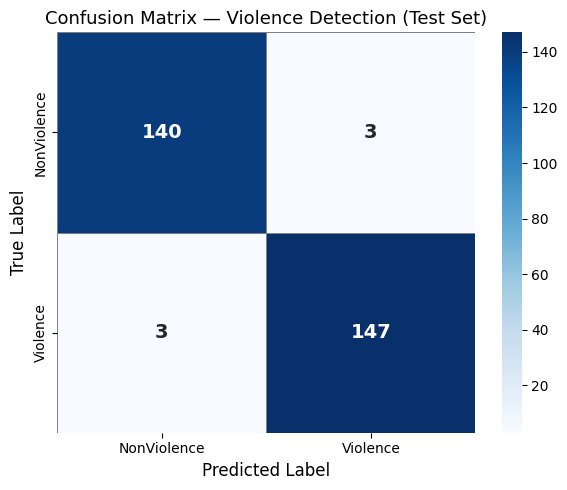

Saved as confusion_matrix_v2.png


In [16]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, linecolor='gray',
            annot_kws={"size": 14, "weight": "bold"})

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Confusion Matrix — Violence Detection (Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix_v2.png', dpi=150)
plt.show()
print("Saved as confusion_matrix_v2.png")
